TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded: /kaggle/input/chest-xray-pneumonia

Validating image files...
Valid images: 11712
Invalid images skipped: 5856

Class distribution:
label
PNEUMONIA    8546
NORMAL       3166
Name: count, dtype: int64


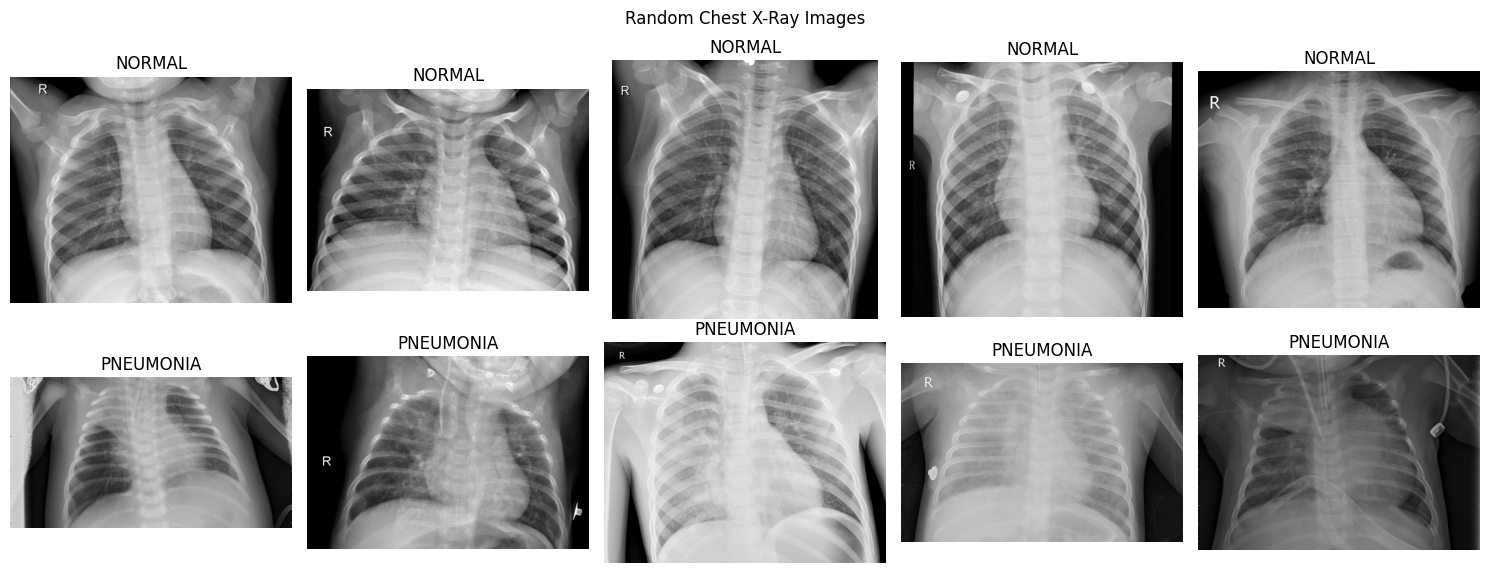

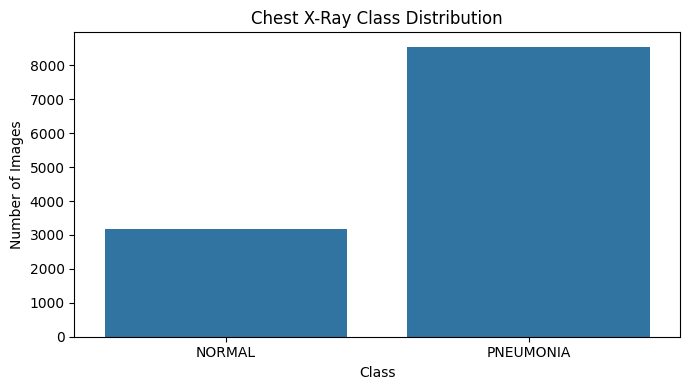


Preprocessing and extracting features...
Processed 500/11712
Processed 1000/11712
Processed 1500/11712
Processed 2000/11712
Processed 2500/11712
Processed 3000/11712
Processed 3500/11712
Processed 4000/11712
Processed 4500/11712
Processed 5000/11712
Processed 5500/11712
Processed 6000/11712
Processed 6500/11712
Processed 7000/11712
Processed 7500/11712
Processed 8000/11712
Processed 8500/11712
Processed 9000/11712
Processed 9500/11712
Processed 10000/11712
Processed 10500/11712
Processed 11000/11712
Processed 11500/11712

Image tensor: (11712, 128, 128, 1)
Feature matrix: (11712, 1822)
Labels: (11712,)

Dataset split:
Training: 8198 (70.00%)
Validation: 1757 (15.00%)
Testing: 1757 (15.00%)

Starting 3-fold CNN cross-validation...
Parameters={'lr': 0.001, 'dropout': 0.3}, Fold=1, AUROC=0.9281
Parameters={'lr': 0.001, 'dropout': 0.3}, Fold=2, AUROC=0.9489
Parameters={'lr': 0.001, 'dropout': 0.3}, Fold=3, AUROC=0.9268
Parameters={'lr': 0.001, 'dropout': 0.5}, Fold=1, AUROC=0.9256
Paramet

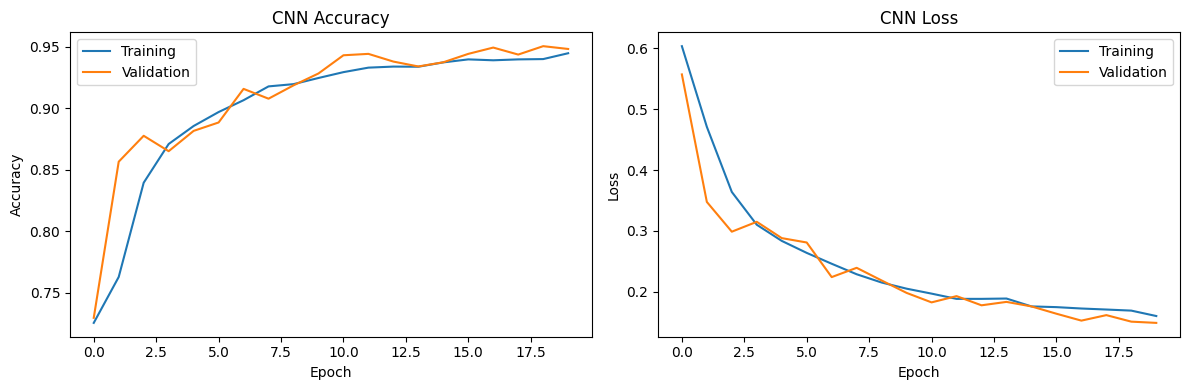


Training SVM...

FINAL TEST RESULTS
                 Model  Accuracy  Precision  Recall  F1-score  AUROC
                   CNN    0.9516     0.9754  0.9579    0.9665 0.9870
HOG + LBP + GLCM + SVM    0.9824     0.9830  0.9930    0.9880 0.9986


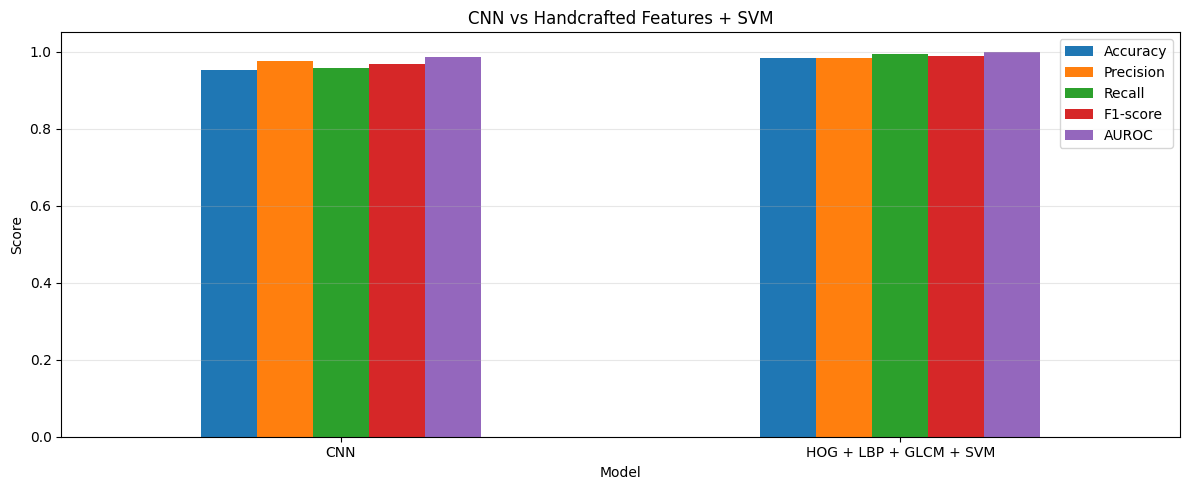

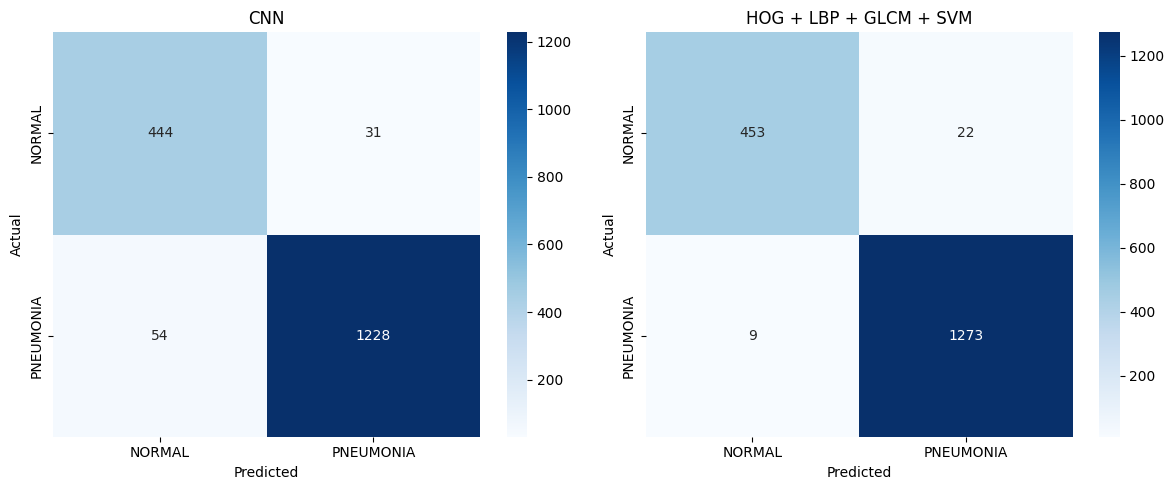

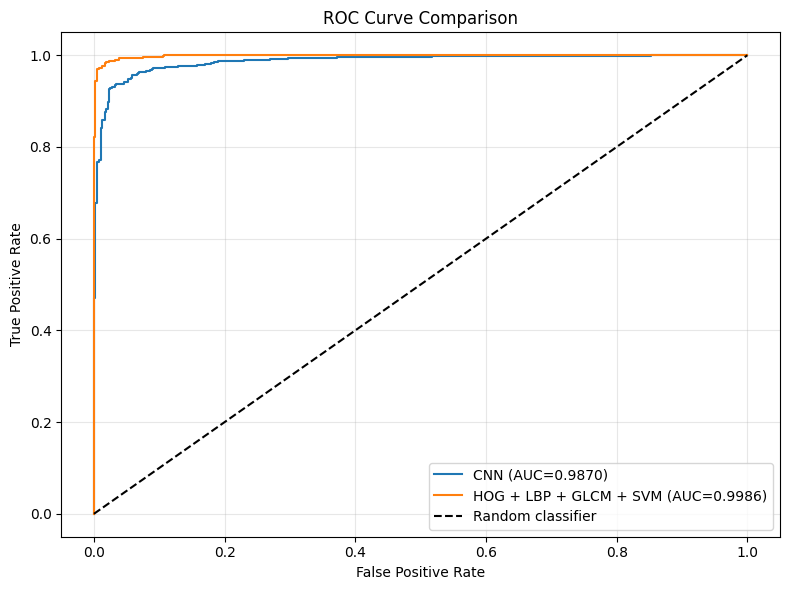


CNN Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.93      0.91       475
   PNEUMONIA       0.98      0.96      0.97      1282

    accuracy                           0.95      1757
   macro avg       0.93      0.95      0.94      1757
weighted avg       0.95      0.95      0.95      1757


SVM Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.95      0.97       475
   PNEUMONIA       0.98      0.99      0.99      1282

    accuracy                           0.98      1757
   macro avg       0.98      0.97      0.98      1757
weighted avg       0.98      0.98      0.98      1757


CNN misclassifications: 85


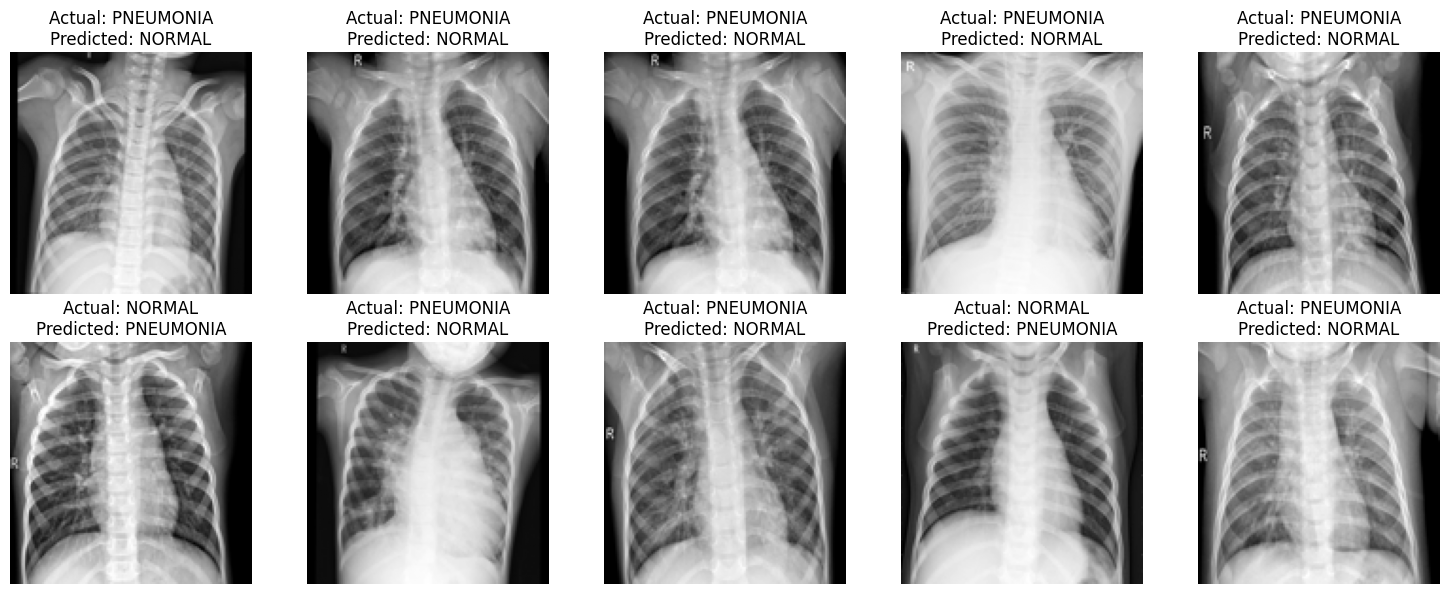


Model with highest test AUROC: HOG + LBP + GLCM + SVM

Saved files:
/content/chest_xray_cnn.keras
/content/chest_xray_svm.pkl
/content/model_comparison.csv
/content/cnn_cv_results.csv

ALL TASKS COMPLETED


In [5]:

!pip -q install kagglehub scikit-image scikit-learn seaborn

import os, random, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub
import joblib

from pathlib import Path
from PIL import Image, UnidentifiedImageError
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

warnings.filterwarnings("ignore")

# 1. CONFIGURATION
SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# 2. DOWNLOAD DATASET
print("\nDownloading dataset...")
dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)
print("Dataset downloaded:", dataset_path)

# 3. LOAD AND VALIDATE IMAGES
# Corrupted or unreadable images are skipped.

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
records = []
invalid_files = []

print("\nValidating image files...")

for p in Path(dataset_path).rglob("*"):
    if not p.is_file() or p.suffix.lower() not in image_extensions:
        continue

    label = p.parent.name.upper()

    if label not in ["NORMAL", "PNEUMONIA"]:
        continue

    try:
        # Verify file integrity
        with Image.open(p) as img:
            img.verify()

        # Reopen and fully decode the image
        with Image.open(p) as img:
            img.convert("L").load()

        records.append({
            "path": str(p),
            "label": label
        })

    except (UnidentifiedImageError, OSError, ValueError):
        invalid_files.append(str(p))

df = pd.DataFrame(records).drop_duplicates("path")
df = df.reset_index(drop=True)

print("Valid images:", len(df))
print("Invalid images skipped:", len(invalid_files))
print("\nClass distribution:")
print(df["label"].value_counts())

if df.empty:
    raise ValueError("No valid images found.")

# 4. DISPLAY RANDOM IMAGES
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for r, label in enumerate(["NORMAL", "PNEUMONIA"]):
    samples = df[df["label"] == label].sample(
        n=min(5, (df["label"] == label).sum()),
        random_state=SEED
    )

    for c, (_, row) in enumerate(samples.iterrows()):
        try:
            with Image.open(row["path"]) as img:
                axes[r, c].imshow(img.convert("L"), cmap="gray")
            axes[r, c].set_title(label)
            axes[r, c].axis("off")
        except (UnidentifiedImageError, OSError, ValueError):
            axes[r, c].axis("off")

    for c in range(len(samples), 5):
        axes[r, c].axis("off")

plt.suptitle("Random Chest X-Ray Images")
plt.tight_layout()
plt.show()

# 5. CLASS DISTRIBUTION
counts = df["label"].value_counts().reindex(
    ["NORMAL", "PNEUMONIA"], fill_value=0
)

plt.figure(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Chest X-Ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# 6. IMAGE PREPROCESSING
def preprocess_image(path):
    with Image.open(path) as img:
        img = img.convert("L").resize(IMG_SIZE)
        return np.asarray(img, dtype=np.uint8)

# 7. FEATURE EXTRACTION: HOG, LBP, GLCM
def extract_features(img):

    # HOG
    h = hog(
        img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    # LBP
    lbp = local_binary_pattern(
        img, P=8, R=1, method="uniform"
    )
    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0, 10),
        density=True
    )

    # GLCM
    quantized = (img // 16).astype(np.uint8)
    glcm = graycomatrix(
        quantized,
        distances=[1, 3],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=16,
        symmetric=True,
        normed=True
    )

    g = []
    for prop in [
        "contrast", "dissimilarity", "homogeneity",
        "energy", "correlation", "ASM"
    ]:
        g.extend(graycoprops(glcm, prop).flatten())

    return np.concatenate([h, lbp_hist, g]).astype(np.float32)

# 8. PROCESS ALL VALID IMAGES
X_img, X_feat, y = [], [], []
label_map = {"NORMAL": 0, "PNEUMONIA": 1}

print("\nPreprocessing and extracting features...")

for i, row in enumerate(df.itertuples(index=False)):
    try:
        img = preprocess_image(row.path)
        features = extract_features(img)

        X_img.append(img[..., np.newaxis] / 255.0)
        X_feat.append(features)
        y.append(label_map[row.label])

    except (UnidentifiedImageError, OSError, ValueError) as e:
        # A second check protects against files that become
        # unreadable between validation and preprocessing.
        print("Skipping unreadable image:", row.path)
        continue

    if (i + 1) % 500 == 0:
        print(f"Processed {i+1}/{len(df)}")

X_img = np.asarray(X_img, dtype=np.float32)
X_feat = np.asarray(X_feat, dtype=np.float32)
y = np.asarray(y, dtype=np.int32)

print("\nImage tensor:", X_img.shape)
print("Feature matrix:", X_feat.shape)
print("Labels:", y.shape)

if len(y) == 0 or len(np.unique(y)) != 2:
    raise ValueError("Both classes must have valid images.")

# 9. TRAIN / VALIDATION / TEST SPLIT (70:15:15)
indices = np.arange(len(y))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y[temp_idx],
    random_state=SEED
)

X_train, y_train = X_img[train_idx], y[train_idx]
X_val, y_val = X_img[val_idx], y[val_idx]
X_test, y_test = X_img[test_idx], y[test_idx]

F_train = X_feat[train_idx]
F_val = X_feat[val_idx]
F_test = X_feat[test_idx]

print("\nDataset split:")
for name, idx in [
    ("Training", train_idx),
    ("Validation", val_idx),
    ("Testing", test_idx)
]:
    print(f"{name}: {len(idx)} ({100*len(idx)/len(y):.2f}%)")

# 10. CNN ARCHITECTURE
def build_cnn(lr=0.001, dropout=0.4):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 1)),

        tf.keras.layers.Conv2D(
            32, 3, padding="same", activation="relu"
        ),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(
            64, 3, padding="same", activation="relu"
        ),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(
            128, 3, padding="same", activation="relu"
        ),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(
            128, activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(0.001)
        ),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

# 11. HYPERPARAMETER TUNING USING 3-FOLD CV
param_grid = [
    {"lr": 0.001, "dropout": 0.3},
    {"lr": 0.001, "dropout": 0.5},
    {"lr": 0.0001, "dropout": 0.3},
    {"lr": 0.0001, "dropout": 0.5}
]

skf = StratifiedKFold(
    n_splits=3, shuffle=True, random_state=SEED
)

cv_results = []

print("\nStarting 3-fold CNN cross-validation...")

for params in param_grid:
    fold_aucs = []

    for fold, (tr, va) in enumerate(
        skf.split(X_train, y_train), start=1
    ):
        tf.keras.backend.clear_session()

        cv_model = build_cnn(**params)

        cv_model.fit(
            X_train[tr], y_train[tr],
            validation_data=(X_train[va], y_train[va]),
            epochs=5,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        prob = cv_model.predict(
            X_train[va], batch_size=BATCH_SIZE, verbose=0
        ).ravel()

        auc = roc_auc_score(y_train[va], prob)
        fold_aucs.append(auc)

        print(
            f"Parameters={params}, Fold={fold}, "
            f"AUROC={auc:.4f}"
        )

        del cv_model
        gc.collect()

    cv_results.append({
        **params,
        "mean_cv_auroc": np.mean(fold_aucs)
    })

cv_df = pd.DataFrame(cv_results).sort_values(
    "mean_cv_auroc", ascending=False
)

print("\nCross-validation results:")
print(cv_df.to_string(index=False))

best_params = {
    "lr": float(cv_df.iloc[0]["lr"]),
    "dropout": float(cv_df.iloc[0]["dropout"])
}
print("\nSelected parameters:", best_params)

# 12. TRAIN FINAL CNN
tf.keras.backend.clear_session()
model = build_cnn(**best_params)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

print("\nTraining final CNN...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# 13. TRAINING AND VALIDATION CURVES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# 14. TRAIN SVM USING HOG + LBP + GLCM
print("\nTraining SVM...")
svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=SEED
    )
)
svm.fit(F_train, y_train)

# 15. PREDICTIONS ON TEST SET
cnn_prob = model.predict(
    X_test, batch_size=BATCH_SIZE, verbose=0
).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

svm_prob = svm.predict_proba(F_test)[:, 1]
svm_pred = svm.predict(F_test)

# 16. EVALUATION METRICS
def evaluate(name, yt, yp, prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(yt, yp),
        "Precision": precision_score(
            yt, yp, zero_division=0
        ),
        "Recall": recall_score(
            yt, yp, zero_division=0
        ),
        "F1-score": f1_score(
            yt, yp, zero_division=0
        ),
        "AUROC": roc_auc_score(yt, prob)
    }

results = pd.DataFrame([
    evaluate("CNN", y_test, cnn_pred, cnn_prob),
    evaluate(
        "HOG + LBP + GLCM + SVM",
        y_test, svm_pred, svm_prob
    )
])

print("\nFINAL TEST RESULTS")
print(results.round(4).to_string(index=False))

# 17. COMPARISON OF MODELS
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score", "AUROC"]
].plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    rot=0
)
plt.title("CNN vs Handcrafted Features + SVM")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 18. CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, pred in [
    (axes[0], "CNN", cnn_pred),
    (axes[1], "HOG + LBP + GLCM + SVM", svm_pred)
]:
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["NORMAL", "PNEUMONIA"],
        yticklabels=["NORMAL", "PNEUMONIA"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# 19. ROC CURVES
plt.figure(figsize=(8, 6))

for name, prob in [
    ("CNN", cnn_prob),
    ("HOG + LBP + GLCM + SVM", svm_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 20. CLASSIFICATION REPORTS
print("\nCNN Classification Report:")
print(classification_report(
    y_test, cnn_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    zero_division=0
))

print("\nSVM Classification Report:")
print(classification_report(
    y_test, svm_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    zero_division=0
))

# 21. MISCLASSIFIED CNN IMAGES
wrong = np.where(cnn_pred != y_test)[0]
print("\nCNN misclassifications:", len(wrong))

if len(wrong) > 0:
    selected = wrong[:10]
    ncols = 5
    nrows = int(np.ceil(len(selected) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(15, 3 * nrows)
    )
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, selected):
        ax.imshow(X_test[i].squeeze(), cmap="gray")
        actual = "PNEUMONIA" if y_test[i] else "NORMAL"
        predicted = "PNEUMONIA" if cnn_pred[i] else "NORMAL"
        ax.set_title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 22. SAVE MODELS AND RESULTS
model.save("/content/chest_xray_cnn.keras")
joblib.dump(svm, "/content/chest_xray_svm.pkl")
results.to_csv("/content/model_comparison.csv", index=False)
cv_df.to_csv("/content/cnn_cv_results.csv", index=False)

print("\nModel with highest test AUROC:",
      results.loc[results["AUROC"].idxmax(), "Model"])
print("\nSaved files:")
print("/content/chest_xray_cnn.keras")
print("/content/chest_xray_svm.pkl")
print("/content/model_comparison.csv")
print("/content/cnn_cv_results.csv")
print("\nALL TASKS COMPLETED")